In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from gwgraphs import *

In [2]:
def read_graph_data():
    # Read the adjacency matrix (edges)
    with open("COX2_A.txt", "r") as f:
        edges = [tuple(map(int, line.split(','))) for line in f]

    # Read graph indicators
    with open("COX2_graph_indicator.txt", "r") as f:
        graph_indicators = [int(line.strip()) for line in f if line.strip()]

    # Read graph labels
    with open("COX2_graph_labels.txt", "r") as f:
        graph_labels = [int(line.strip()) for line in f]

    # Read node labels
    with open("COX2_node_labels.txt", "r") as f:
        node_labels = [int(line.strip()) for line in f]

    return edges, graph_indicators, graph_labels, node_labels


def construct_networkx_graph(edges, graph_indicators, graph_labels,
                             node_labels):
    graphs = {}
    for node_id, graph_id in enumerate(graph_indicators, start=1):
        if graph_id not in graphs:
            graphs[graph_id] = nx.Graph(label=graph_labels[graph_id - 1])

    for edge in edges:
        node1, node2 = edge
        graph_id = graph_indicators[
            node1 - 1]  # Determine which graph the edge belongs to
        graphs[graph_id].add_edge(node1, node2)

    for node_id, (graph_id,
                  node_label) in enumerate(zip(graph_indicators, node_labels),
                                           start=1):
        graphs[graph_id].nodes[node_id]['label'] = node_label

    return graphs


def compute_averages(graphs):
    # Initialize variables
    total_nodes = 0
    class_nodes = {}
    class_counts = {}
    # Iterate through graphs to compute totals
    for graph_id, graph in graphs.items():
        num_nodes = graph.number_of_nodes()
        total_nodes += num_nodes
        
        # Get the class label for the current graph
        graph_label = graph.graph['label']
        
        if graph_label not in class_nodes:
            class_nodes[graph_label] = 0
            class_counts[graph_label] = 0
        
        class_nodes[graph_label] += num_nodes
        class_counts[graph_label] += 1
    # Calculate total average
    total_avg = round(total_nodes / len(graphs))
    
    # Calculate class-based averages
    class_averages = {label: round(class_nodes[label] / count)
                      for label, count in class_counts.items()}
    
    return total_avg, class_averages


def compute_distance_matrix(graph):
    num_nodes = len(graph.nodes)
    distance_matrix = np.full((num_nodes, num_nodes), 10000.0)

    # Get the correct node indices to be used for indexing the matrix
    node_list = list(graph.nodes())
    node_index = {node: i for i, node in enumerate(node_list)}

    for node in graph.nodes:
        lengths = nx.shortest_path_length(graph, source=node, weight="weight")

        for target, length in lengths.items():
            if target in node_index:
                distance_matrix[node_index[node], node_index[target]] = length

    return distance_matrix


def compute_graph_stats(graphs):
    # Initialize counters
    total_edges = 0
    total_nodes = 0
    class1_edges = 0
    class1_nodes = 0
    classm1_edges = 0
    classm1_nodes = 0

    # Collect degrees for plotting
    all_degrees = []
    class1_degrees = []
    classm1_degrees = []

    for graph in graphs.values():
        num_edges = graph.number_of_edges()
        num_nodes = graph.number_of_nodes()
        degrees = [d for n, d in graph.degree()]

        total_edges += num_edges
        total_nodes += num_nodes
        all_degrees.extend(degrees)

        if graph.graph['label'] == 1:
            class1_edges += num_edges
            class1_nodes += num_nodes
            class1_degrees.extend(degrees)
        else:
            classm1_edges += num_edges
            classm1_nodes += num_nodes
            classm1_degrees.extend(degrees)

    # Calculate statistics
    edge_density = (2 * total_edges) / (total_nodes * (total_nodes - 1))
    avg_degree = 2 * total_edges / total_nodes
    avg_degree_class1 = 2 * class1_edges / class1_nodes if class1_nodes > 0 else 0
    avg_degree_classm1 = 2 * classm1_edges / classm1_nodes if classm1_nodes > 0 else 0

    print(f"\nGraph Statistics:")
    print(f"Edge Density: {edge_density:.4f}")
    print(f"Average Degree (Full Dataset): {avg_degree:.2f}")
    print(f"Average Degree (Class 1): {avg_degree_class1:.2f}")
    print(f"Average Degree (Class -1): {avg_degree_classm1:.2f}")

    # Plot degree distributions

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Full dataset degree distribution
    ax1.hist(all_degrees, bins=30, alpha=0.7, color='blue', label='All')
    ax1.set_title('Degree Distribution (Full Dataset)')
    ax1.set_xlabel('Degree')
    ax1.set_ylabel('Frequency')
    ax1.legend()

    # Class-wise degree distribution
    bins = np.linspace(min(all_degrees), max(all_degrees), 31)
    class1_hist, _ = np.histogram(class1_degrees, bins=bins)
    classm1_hist, _ = np.histogram(classm1_degrees, bins=bins)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    width = (bins[1] - bins[0]) * 0.35

    ax2.bar(bin_centers - width/2, class1_hist, width, color='gray', label='Class 1')
    ax2.bar(bin_centers + width/2, classm1_hist, width, color='purple', label='Class -1')
    ax2.set_title('Degree Distribution by Class')
    ax2.set_xlabel('Degree')
    ax2.set_ylabel('Frequency')
    ax2.legend()

    plt.tight_layout()
    plt.savefig('degree_distributions.png')
    plt.show()
    plt.close()

In [3]:
edges, graph_indicators, graph_labels, node_labels = read_graph_data()
graphs = construct_networkx_graph(edges, graph_indicators, graph_labels,
                                      node_labels)
for graph_id, graph in graphs.items():
    print(
        f"Graph ID: {graph_id}, number of nodes: {graph.number_of_nodes()}, label: {graph.graph['label']}"
        )
total_avg, class_averages = compute_averages(graphs)
print(f"Average number of nodes in entire dataset: {total_avg}")
print("Average number of nodes for each class:")
for class_label, avg_nodes in class_averages.items():
        print(f"  Class {class_label}: {avg_nodes}")

Graph ID: 1, number of nodes: 39, label: -1
Graph ID: 2, number of nodes: 36, label: -1
Graph ID: 3, number of nodes: 36, label: 1
Graph ID: 4, number of nodes: 39, label: -1
Graph ID: 5, number of nodes: 42, label: -1
Graph ID: 6, number of nodes: 42, label: -1
Graph ID: 7, number of nodes: 44, label: -1
Graph ID: 8, number of nodes: 39, label: -1
Graph ID: 9, number of nodes: 42, label: 1
Graph ID: 10, number of nodes: 42, label: 1
Graph ID: 11, number of nodes: 45, label: 1
Graph ID: 12, number of nodes: 49, label: 1
Graph ID: 13, number of nodes: 42, label: 1
Graph ID: 14, number of nodes: 35, label: -1
Graph ID: 15, number of nodes: 44, label: 1
Graph ID: 16, number of nodes: 47, label: 1
Graph ID: 17, number of nodes: 45, label: 1
Graph ID: 18, number of nodes: 39, label: 1
Graph ID: 19, number of nodes: 44, label: -1
Graph ID: 20, number of nodes: 44, label: -1
Graph ID: 21, number of nodes: 51, label: -1
Graph ID: 22, number of nodes: 45, label: -1
Graph ID: 23, number of nodes

In [4]:
graphs_list = []
labels_list = []
for graph_id, graph in graphs.items():
    # Add the graph object to the list
    graphs_list.append(graph)

    # Extract the label and add to the label list
    label = graph.graph['label']
    labels_list.append(label)

# Convert graphs into pairwise distance matrices
distance_matrices = [compute_distance_matrix(graph) for graph in graphs_list]
# Determine number of elements of each class
print("Elements of Class 1: ", labels_list.count(1))
print("Elements of Class -1: ", labels_list.count(-1))

Elements of Class 1:  102
Elements of Class -1:  365



Graph Statistics:
Edge Density: 0.0001
Average Degree (Full Dataset): 2.11
Average Degree (Class 1): 2.10
Average Degree (Class -1): 2.11


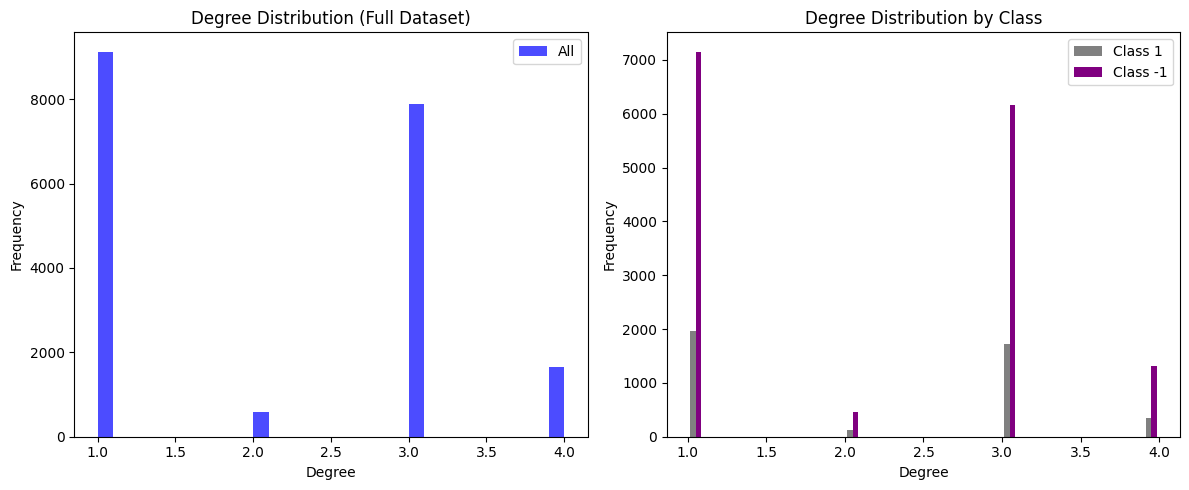

In [5]:
# Compute and display graph statistics
compute_graph_stats(graphs)

In [6]:
# Balance the dataset by selecting equal numbers from each class
class_1_indices = [i for i, label in enumerate(labels_list) if label == 1]
class_neg1_indices = [i for i, label in enumerate(labels_list) if label == -1]

# Randomly select 102 elements from class -1 to match class 1
random.seed(42)  # Set seed for reproducibility
selected_neg1_indices = random.sample(class_neg1_indices, 102)

# Combine selected indices
balanced_indices = class_1_indices + selected_neg1_indices
random.shuffle(balanced_indices)  # Shuffle to mix the classes

# Create balanced dataset
balanced_graphs_list = [graphs_list[i] for i in balanced_indices]
balanced_labels_list = [labels_list[i] for i in balanced_indices]
balanced_distance_matrices = [distance_matrices[i] for i in balanced_indices]

print(f"\nBalanced dataset:")
print("Elements of Class 1: ", balanced_labels_list.count(1))
print("Elements of Class -1: ", balanced_labels_list.count(-1))

# Update the variables to use balanced data
graphs_list = balanced_graphs_list
labels_list = balanced_labels_list
distance_matrices = balanced_distance_matrices


Balanced dataset:
Elements of Class 1:  102
Elements of Class -1:  102


In [7]:
### kNN with COX2 data ###

In [8]:
k_list = [1,2,3,4,5,6,7,8,9,10]
num_folds = 10

In [10]:
accuracies, by_class_accuracies, f1scores, best_k_info = gw_knn(distance_matrices, labels_list, num_folds, k_list=k_list, method = "kfold")

k-fold CV selected
Fold 0:
k=1, Class 1 Accuracy: 62.5%, Fold 0
k=1, Class -1 Accuracy: 69.23076923076923%, Fold 0
k=1, Overall Classification Accuracy: 66.66666666666666%, Fold 0
k=1, F1 Score (macro avg): 65.41%, Fold 0
k=2, Class 1 Accuracy: 62.5%, Fold 0
k=2, Class -1 Accuracy: 69.23076923076923%, Fold 0
k=2, Overall Classification Accuracy: 66.66666666666666%, Fold 0
k=2, F1 Score (macro avg): 65.41%, Fold 0
k=3, Class 1 Accuracy: 87.5%, Fold 0
k=3, Class -1 Accuracy: 84.61538461538461%, Fold 0
k=3, Overall Classification Accuracy: 85.71428571428571%, Fold 0
k=3, F1 Score (macro avg): 85.18%, Fold 0
k=4, Class 1 Accuracy: 75.0%, Fold 0
k=4, Class -1 Accuracy: 76.92307692307693%, Fold 0
k=4, Overall Classification Accuracy: 76.19047619047619%, Fold 0
k=4, F1 Score (macro avg): 75.29%, Fold 0
k=5, Class 1 Accuracy: 62.5%, Fold 0
k=5, Class -1 Accuracy: 84.61538461538461%, Fold 0
k=5, Overall Classification Accuracy: 76.19047619047619%, Fold 0
k=5, F1 Score (macro avg): 74.07%, Fold 

In [11]:
### kNN with gLGW distance ###
## CITATION ###
# https://github.com/Gorgotha/LGW #
# lgw_procedure, LGW_graph, and LGW_eucl are taken directly from this code.
# k_folds_glgw_knn is a modified function from the above code. Everything else is my work.

In [12]:
# Normalize the matrices
Ms = []
for matrix in distance_matrices:
    Ms.append(matrix / np.max(matrix))

In [14]:
k_bary = 41  # use overall dataset average
heights = [
    np.full(len(graph), 1 / len(graph)) for graph in graphs_list
]
num_folds = 10

accuracies2, by_class_accuracies2, f1scores2, best_k_info2 = k_folds_glgw_knn(distance_matrices,
            labels_list,
            k_bary,
            Ms,
            heights,
            num_folds,
            seed=42,
            k_knn_list=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            method = "kfold")

k-fold CV selected
Fold 0:
Time taken for reference barycenter computation: 2.3263 seconds
Time taken for LGW computation: 0.8873 seconds
k=1, Class 1 Accuracy: 50.0%
k=1, Class -1 Accuracy: 100.0%
k=1, Overall Classification Accuracy: 80.95238095238095%
k=1, F1 Score (macro avg): 76.67%
k=2, Class 1 Accuracy: 50.0%
k=2, Class -1 Accuracy: 100.0%
k=2, Overall Classification Accuracy: 80.95238095238095%
k=2, F1 Score (macro avg): 76.67%
k=3, Class 1 Accuracy: 75.0%
k=3, Class -1 Accuracy: 92.3076923076923%
k=3, Overall Classification Accuracy: 85.71428571428571%
k=3, F1 Score (macro avg): 84.44%
k=4, Class 1 Accuracy: 50.0%
k=4, Class -1 Accuracy: 100.0%
k=4, Overall Classification Accuracy: 80.95238095238095%
k=4, F1 Score (macro avg): 76.67%
k=5, Class 1 Accuracy: 37.5%
k=5, Class -1 Accuracy: 92.3076923076923%
k=5, Overall Classification Accuracy: 71.42857142857143%
k=5, F1 Score (macro avg): 65.00%
k=6, Class 1 Accuracy: 37.5%
k=6, Class -1 Accuracy: 100.0%
k=6, Overall Classificati